In [1]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit_aer.primitives import Sampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd

In [2]:
df = pd.read_csv("NIFTY50_all.csv", parse_dates=["Date"])

#Keep only relevant columns
df = df[["Date", "Symbol", "Close"]]

df.head()

,Date,Symbol,Close
0,2007-11-27,MUNDRAPORT,962.90
1,2007-11-28,MUNDRAPORT,893.90
2,2007-11-29,MUNDRAPORT,884.20
3,2007-11-30,MUNDRAPORT,921.55
4,2007-12-03,MUNDRAPORT,969.30


In [3]:
prices = df.pivot(index="Date", columns="Symbol", values="Close")
prices.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJAUTOFIN,BAJFINANCE,BHARTI,BHARTIARTL,BPCL,...,TISCO,TITAN,ULTRACEMCO,UNIPHOS,UPL,UTIBANK,VEDL,WIPRO,ZEEL,ZEETELE
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,381.65,NaN,NaN,NaN,50.75,NaN,NaN,NaN,399.25,...,152.45,155.70,NaN,NaN,NaN,26.70,NaN,2724.20,NaN,1179.95
2000-01-04,NaN,385.55,NaN,NaN,NaN,48.10,NaN,NaN,NaN,370.50,...,150.80,147.40,NaN,NaN,NaN,26.85,NaN,2942.15,NaN,1260.65
2000-01-05,NaN,383.00,NaN,NaN,NaN,44.60,NaN,NaN,NaN,359.95,...,156.55,138.40,NaN,NaN,NaN,26.30,NaN,2990.10,NaN,1176.55
2000-01-06,NaN,377.50,NaN,NaN,NaN,45.25,NaN,NaN,NaN,380.30,...,168.25,149.50,NaN,NaN,NaN,25.95,NaN,2932.25,NaN,1115.45
2000-01-07,NaN,385.70,NaN,NaN,NaN,42.90,NaN,NaN,NaN,379.85,...,171.95,146.35,NaN,NaN,NaN,24.80,NaN,2697.70,NaN,1026.25


In [4]:
start_date = "2007-01-01"
end_date = "2019-12-31"
prices = prices.loc[start_date:end_date]
valid_stocks = prices.iloc[0].dropna().index
prices = prices[valid_stocks]

In [5]:
print(f"Dropped {len(df['Symbol'].unique()) - len(valid_stocks)} stocks because they weren't listed by {start_date}.")

Dropped 22 stocks because they weren't listed by 2007-01-01.


In [6]:
na_cols = list(prices.columns[prices.isnull().sum() > 0])
prices.drop(columns=na_cols, inplace=True)
returns = prices.pct_change().dropna()
train = returns.iloc[:int(0.8*len(returns))]
test__start_date = train.index[-1]
test = returns.iloc[int(0.8*len(returns)):]
test_end_date = test.index[-1]

In [7]:
mu = returns.mean().values  
sigma = returns.cov().values
num_assets = len(mu)

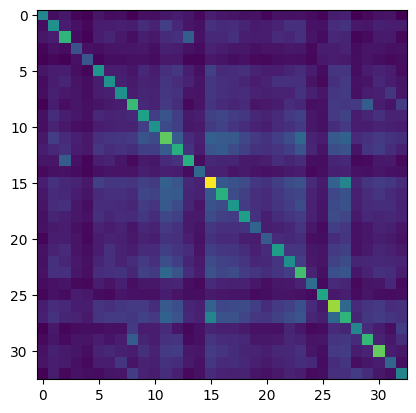

In [8]:
plt.imshow(sigma, interpolation="nearest")
plt.show()

## Small Number of Assests

In [22]:
num_test_assets = 10
mu = returns.mean().values[:num_test_assets]
sigma = returns.cov().values[:num_test_assets, :num_test_assets]
num_assets = len(mu)

In [23]:
q = 0.5  # set risk factor
budget = num_assets // 2  # set budget
penalty = num_assets  # set parameter to scale the budget penalty term

portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
qp

<QuadraticProgram: minimize 0.00027303389950523944*x_0^2 + 7.772096988705501e-..., 10 variables, 1 constraints, 'Portfolio optimization'>

In [ ]:
# initial_holdings = [0, 2] 
# lambda_turnover = 0.01  # Penalty coefficient
# transaction_cost = 0.005 # Linear cost per trade

# for i in range(num_assets):
#     if i in initial_holdings:
#         # If we sell it, we pay. Objective is minimized, so 'selling' 
#         # (changing 1 to 0) should decrease the penalty.
#         # We represent |1 - x| as (1 - x).
#         qp.objective.linear[i] -= (lambda_turnover + transaction_cost)
#     else:
#         # If we buy it, we pay.
#         qp.objective.linear[i] += (lambda_turnover + transaction_cost)

In [24]:
def print_result(result):
    selection = result.x
    value = result.fval
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    eigenstate = result.min_eigen_solver_result.eigenstate
    probabilities = (
        eigenstate.binary_probabilities()
        if isinstance(eigenstate, QuasiDistribution)
        else {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}
    )
    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")
    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in probabilities:
        x = np.array([int(i) for i in list(reversed(k))])
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

In [25]:
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

result = exact_eigensolver.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1. 1. 1. 0. 0. 0. 1.], value -0.0018

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
[1 0 0 1 1 1 0 0 0 1]	-0.0018		1.0000


In [26]:
def print_result(result):
    selection = result.x
    value = result.fval
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    # Updated logic for Qiskit Algorithms 0.3.0+
    # The eigenstate in the result is now typically a dict or QuasiDistribution
    probabilities = result.min_eigen_solver_result.eigenstate
    
    # If it's a list (common in new primitives), take the first distribution
    if isinstance(probabilities, list):
        probabilities = probabilities[0]

    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")
    
    # Sort by probability descending
    sorted_probs = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in sorted_probs:
        # Convert bitstring or integer key to the selection array
        if isinstance(k, str):
            # If key is a bitstring (e.g., '1001')
            x = np.array([int(i) for i in list(reversed(k))])
        else:
            # If key is an integer, convert to binary representation
            bin_str = bin(k)[2:].zfill(num_assets)
            x = np.array([int(i) for i in list(reversed(bin_str))])
            
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

In [ ]:
from qiskit_algorithms.utils import algorithm_globals
from qiskit_algorithms import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorSampler # Using the V2 Sampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer

# 1. Set the global seed for reproducibility
algorithm_globals.random_seed = 1234

# 2. Define the Optimizer
cobyla = COBYLA(maxiter=500)

# 3. Define the Ansatz (Variational Form)
ansatz = TwoLocal(num_assets, "ry", "cz", reps=5, entanglement="full")

# 4. Initialize the V2 Sampler
sampler = StatevectorSampler()

# 5. Initialize SamplingVQE
svqe_mes = SamplingVQE(sampler=sampler, ansatz=ansatz, optimizer=cobyla)

# 6. Wrap in the Optimizer and Solve
svqe = MinimumEigenOptimizer(svqe_mes)
result = svqe.solve(qp)

print_result(result)

C:\Users\ahing\AppData\Local\Temp\ipykernel_36452\1292322290.py:16: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_assets, "ry", "cz", reps=5, entanglement="full")


Optimal: selection [1. 0. 0. 1. 1. 1. 0. 0. 1. 0.], value -0.0017

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
[0 0 1 0 1 1 1 1 0 0]	-0.0003		0.0176
[0 1 1 0 0 0 1 0 1 0]	0.0008		0.0156
[0 0 1 0 1 1 1 0 0 1]	-0.0008		0.0156
[0 1 1 1 1 1 0 1 0 1]	0.0003		0.0117
[0 1 0 0 1 1 1 1 0 0]	-0.0001		0.0117
[1 1 1 0 0 0 0 0 1 0]	-0.0001		0.0107
[1 1 0 1 0 1 0 0 1 1]	-0.0007		0.0107
[1 0 0 1 0 0 0 0 1 1]	-0.0005		0.0098
[0 1 0 1 1 0 1 1 0 1]	0.0014		0.0098
[0 0 0 0 1 1 1 1 0 1]	-0.0003		0.0098
[0 1 0 1 1 0 0 1 0 0]	0.0003		0.0098
[1 1 0 1 0 0 0 0 1 0]	-0.0002		0.0088
[1 1 1 1 0 0 0 0 1 1]	0.0004		0.0088
[0 1 1 0 0 0 1 1 1 0]	0.0016		0.0088
[0 1 1 0 0 0 1 0 1 1]	0.0012		0.0078
[0 0 1 1 1 1 1 0 0 0]	-0.0009		0.0078
[1 0 1 0 0 0 1 0 1 1]	0.0003		0.0078
[0 0 0 0 1 1 1 0 0 1]	-0.0011		0.0078
[1 0 0 1 0 1 0 0 1 1]	-0.0013		0.0068
[0 1 0 0 1 0 0 0 0 0]	-0.0003		0.0068
[0 1 0 1 1 0 0 1 0 1]	0.0006		0.0068
[1 0 1 1 0 

In [ ]:
help(SamplingVQE)

In [28]:
# 1. Identify which indices have a value of 1 in the result
selected_indices = [i for i, x in enumerate(result.x) if x == 1]

# 2. Map those indices to your ticker names
# Ensure 'valid_stocks' is the index used for your 'mu' and 'sigma'
portfolio_tickers = [valid_stocks[i] for i in selected_indices]

print("Selected Stocks in Portfolio:")
print(portfolio_tickers)

Selected Stocks in Portfolio:
['ASIANPAINT', 'BPCL', 'BRITANNIA', 'CIPLA', 'GAIL']


## Complete Portfolio

In [29]:
mu = train.mean().values  
sigma = train.cov().values
num_assets = len(mu)

In [30]:
q = 0.5  # set risk factor
budget = 5 # set budget
penalty = num_assets  # set parameter to scale the budget penalty term

portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
qp

<QuadraticProgram: minimize 0.0003179879341348956*x_0^2 + 8.1458601913771e-05*..., 33 variables, 1 constraints, 'Portfolio optimization'>

In [33]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler

# 1. Setup Backend with MPS
backend = AerSimulator(method='matrix_product_state')

# 2. Transpile the ansatz specifically for this backend
# This converts the TwoLocal abstract form into actual gates the backend understands
ansatz_opt = transpile(ansatz, backend=backend)

# 3. Setup the Sampler
sampler = AerSampler(backend_options={"method": "matrix_product_state"})

# 4. Pass the transpiled ansatz to SamplingVQE
# Note: Use 'ansatz_opt' instead of 'ansatz'
svqe_mes = SamplingVQE(sampler=sampler, ansatz=ansatz_opt, optimizer=cobyla)

# 5. Solve
svqe = MinimumEigenOptimizer(svqe_mes)
result = svqe.solve(qp)

print_result(result)

c:\Users\ahing\Downloads\Industry Project\.venv\Lib\site-packages\samplomatic\__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


TypeError: Invalid circuits, expected Sequence[QuantumCircuit].